In [32]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Reemplazá por la ruta a tu archivo CSV
ruta_csv = 'F1_Datos_limpios.csv'

# Leer el archivo
df = pd.read_csv(ruta_csv)

# Mostrar información básica
print(f"Cantidad de filas (instancias): {df.shape[0]}")
print(f"Cantidad de columnas (atributos): {df.shape[1]}")
print("\nLista de atributos:")
for col in df.columns:
    print(f"- {col}")

Cantidad de filas (instancias): 25121
Cantidad de columnas (atributos): 92

Lista de atributos:
- raceId
- year
- round
- circuitId
- name_x
- date
- time_x
- circuitRef
- name_y
- location
- country
- lat
- lng
- alt
- resultId
- driverId
- constructorId
- number_x
- grid
- position
- positionText
- positionOrder
- points
- laps
- time_y
- milliseconds
- fastestLap
- rank
- fastestLapTime
- fastestLapSpeed
- statusId
- constructorRef
- name
- nationality_x
- driverRef
- number_y
- code
- forename
- surname
- dob
- nationality_y
- race_datetime
- result_datetime
- race_year
- race_month
- race_day
- race_weekday
- race_hour
- birth_date
- driver_age
- fastestLapTime_sec
- DNF
- win
- circuit_type
- real_points
- position_change
- gap_to_leader
- gap_to_team
- circuit_prev_races
- circuit_prev_dnfs
- circuit_prev_wins
- circuit_prev_avg_pos
- circuit_prev_avg_points
- circuit_prev_dnf_rate
- circuit_prev_win_rate
- last_n_avg_position
- last_n_total_points
- last_n_wins
- last_n_dnfs
- 

C:\Users\salva\AppData\Local\Temp\ipykernel_1932\1866939042.py:9: DtypeWarning: Columns (6,28,41,46,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_csv)


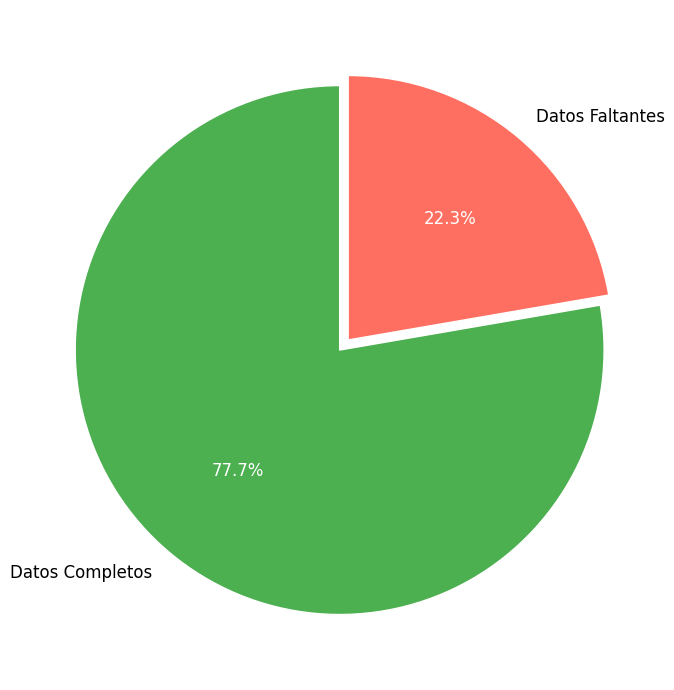

In [ ]:
# Cálculos
total_celdas = df.size
total_faltantes = df.isnull().sum().sum()
total_completos = total_celdas - total_faltantes

# Datos y etiquetas
labels = ['Datos Completos', 'Datos Faltantes']
sizes = [total_completos, total_faltantes]
colors = ['#4CAF50', '#FF6F61']  # Verde y rojo suave
explode = (0, 0.05)  # Resalta la porción de faltantes

# Gráfico de torta
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={'edgecolor': 'white'}
)

# Estilo del texto
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')

plt.title('Proporción general de datos completos vs. faltantes', fontsize=14)
plt.axis('equal')  # Mantiene el círculo
plt.tight_layout()
plt.show()

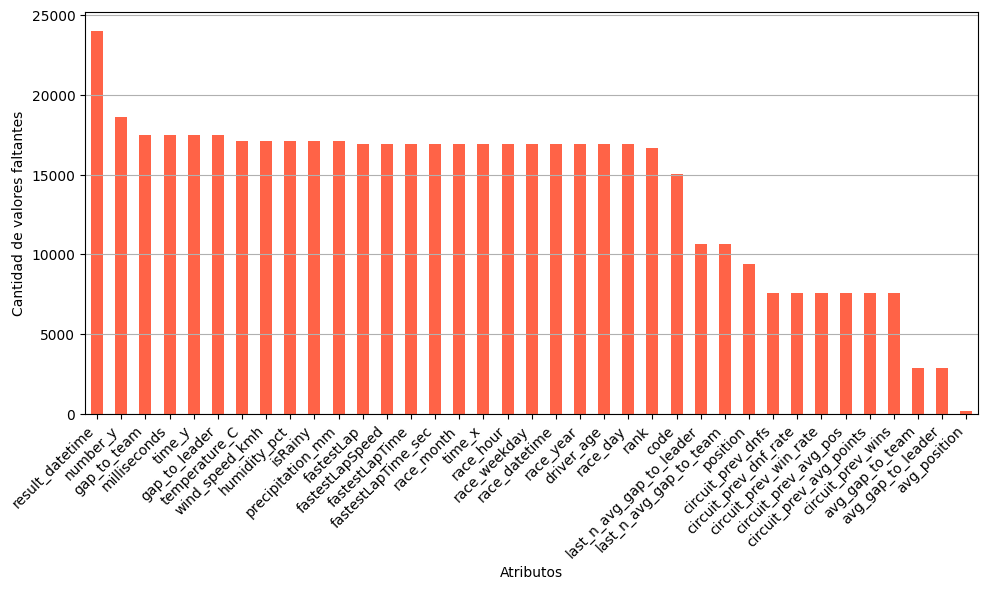

In [28]:
faltantes = df.isnull().sum()

# Filtrar las columnas con al menos un valor faltante
faltantes = faltantes[faltantes > 0]

# Ordenar de mayor a menor
faltantes = faltantes.sort_values(ascending=False)

# Mostrar las columnas con más valores faltantes (ajustable)
faltantes.plot(kind='bar', figsize=(10, 6), color='tomato')

plt.ylabel("Cantidad de valores faltantes")
plt.xlabel("Atributos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

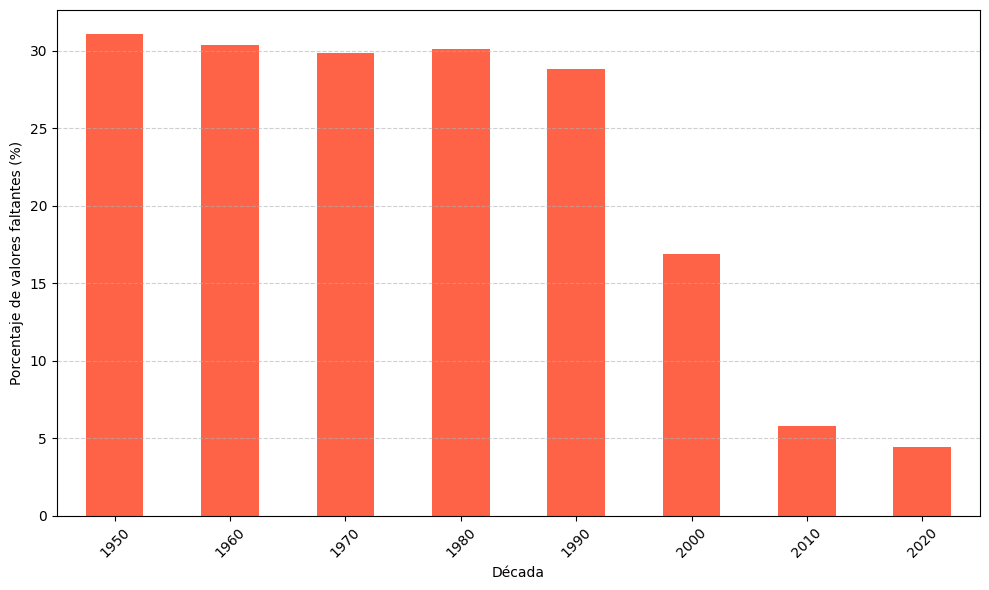

In [30]:
# Asegurate de que el campo de año sea numérico
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Creamos una nueva columna con la década o período
df['period'] = (df['year'] // 10 * 10).astype('Int64')  # ej: 1985 -> 1980

# Calculamos la proporción de valores faltantes por fila
df['missing_rate'] = df.isnull().mean(axis=1)

# Agrupamos por período y promediamos el porcentaje de nulos
missing_by_period = df.groupby('period')['missing_rate'].mean() * 100  # en %

# Graficamos
plt.figure(figsize=(10, 6))
missing_by_period.plot(kind='bar', color='tomato')
plt.xlabel("Década")
plt.ylabel("Porcentaje de valores faltantes (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\salva\AppData\Local\Temp\ipykernel_1932\3877815748.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


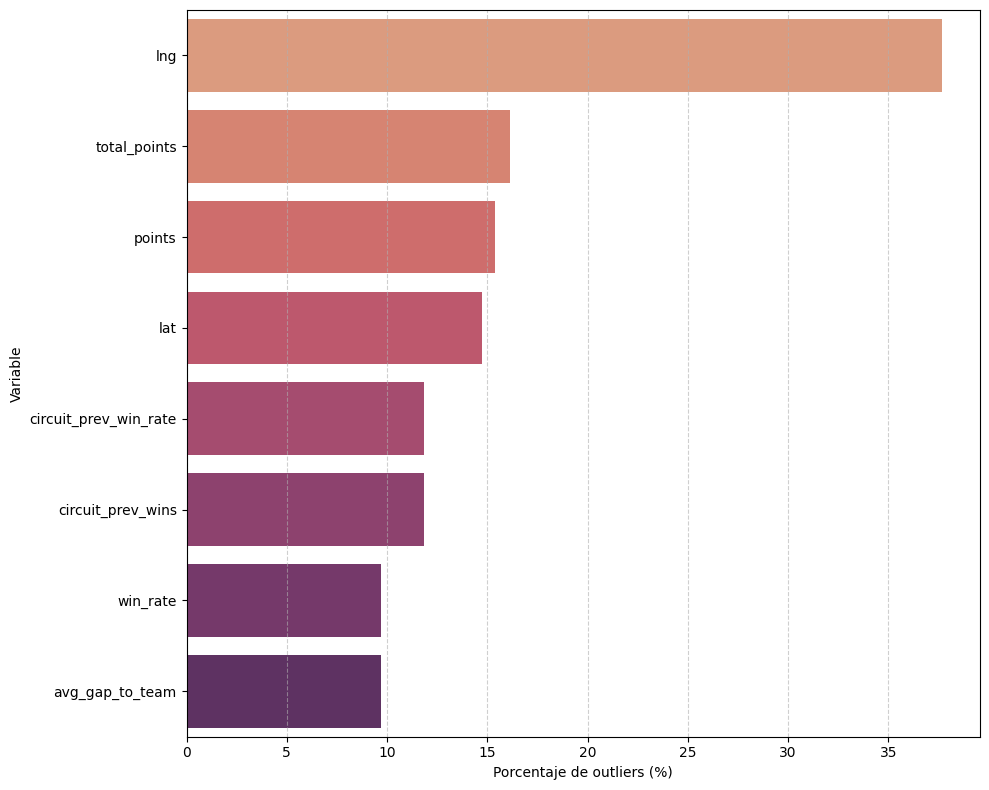

In [50]:
def detectar_outliers_iqr(df):
    # Selecciona columnas numéricas automáticamente
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    
    outliers_dict = {}
    resumen = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        total_outliers = mask_outliers.sum()
        porcentaje = (total_outliers / len(df)) * 100

        resumen.append({
            'Variable': col,
            'Outliers': total_outliers,
            'Porcentaje': round(porcentaje, 2)
        })

        outliers_dict[col] = df[mask_outliers]

    resumen_df = pd.DataFrame(resumen).sort_values(by='Outliers', ascending=False)
    return resumen_df, outliers_dict, numeric_cols

# Ejecutar detección
resumen_outliers, outliers_por_variable, columnas_numericas = detectar_outliers_iqr(df)

# Filtrar solo las variables que tienen al menos un outlier
resumen_filtrado = resumen_outliers[resumen_outliers['Outliers'] > 0]

# Ordenar de mayor a menor
resumen_filtrado = resumen_filtrado.sort_values(by='Porcentaje', ascending=False)

# Graficar solo los primeros 10 atributos con más outliers menos constructor_id y status_id

resumen_filtrado = resumen_filtrado[~resumen_filtrado['Variable'].isin(['constructorId', 'statusId'])]
plt.figure(figsize=(10, 8))
sns.barplot(
    data=resumen_filtrado.head(8),
    y='Variable',
    x='Porcentaje',
    palette='flare'
)
plt.xlabel("Porcentaje de outliers (%)")
plt.ylabel("Variable")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\salva\AppData\Local\Temp\ipykernel_1932\2884196098.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


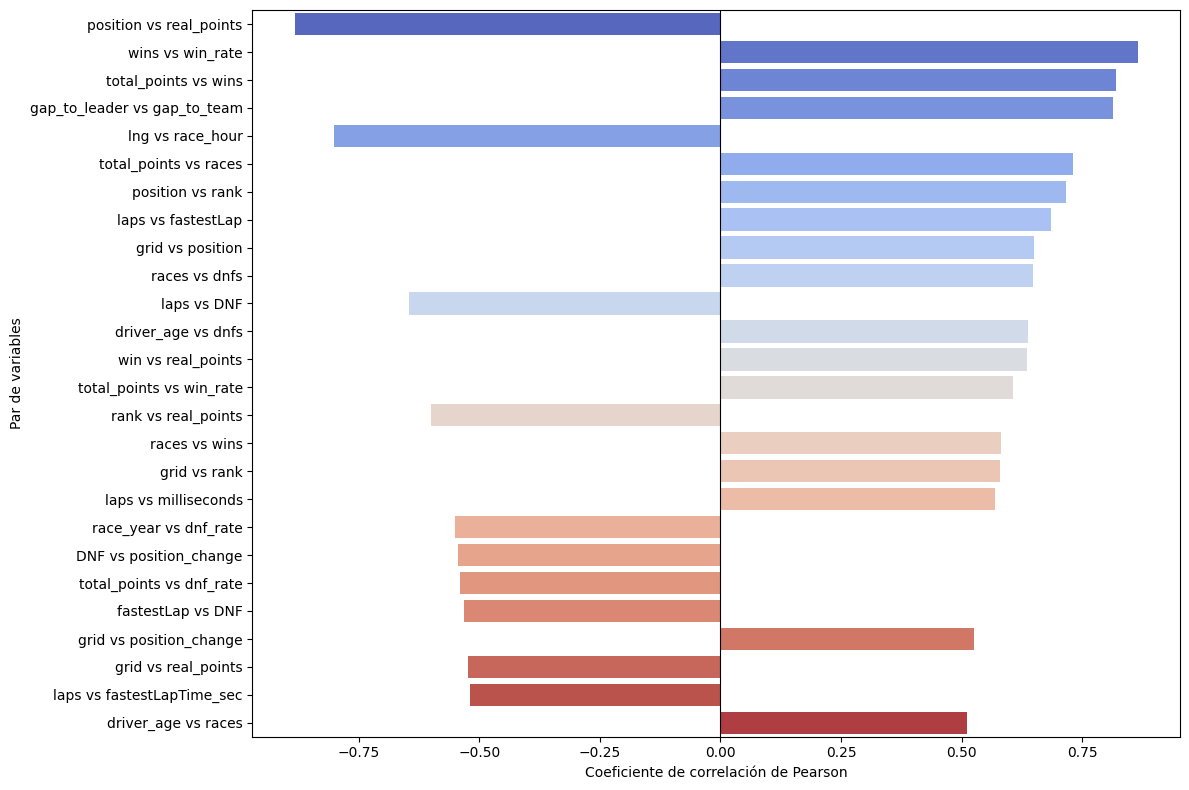

In [62]:
# Calcular la matriz de correlación (sólo variables numéricas)
# Filtrar columnas que no empiecen con los prefijos excluidos
prefijos_excluir = ('avg_', 'last_n_', 'circuit_prev', 'points', 'year', 'positionOrder', 'total_real_points', 'round')
columnas_filtradas = [col for col in df.columns if not col.startswith(prefijos_excluir) and not col.endswith(('Id', 'x', 'y'))]

# Aplicar filtro al DataFrame
df_filtrado = df[columnas_filtradas]

corr_matrix = df_filtrado.corr(numeric_only=True)

# Convertir a una tabla de pares
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']

# Eliminar autocorrelaciones y duplicados
corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]
corr_pairs['Par'] = corr_pairs.apply(lambda row: tuple(sorted([row['Variable 1'], row['Variable 2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='Par')

# Filtrar por fuerza de correlación (opcional)
umbral = 0.5  # solo muestra correlaciones significativas
corr_pairs_filtradas = corr_pairs[abs(corr_pairs['Correlación']) > umbral]

# Ordenar por magnitud de correlación
corr_pairs_filtradas = corr_pairs_filtradas.sort_values(by='Correlación', key=lambda x: abs(x), ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(
    y=corr_pairs_filtradas['Variable 1'] + ' vs ' + corr_pairs_filtradas['Variable 2'],
    x=corr_pairs_filtradas['Correlación'],
    palette='coolwarm'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente de correlación de Pearson')
plt.ylabel('Par de variables')
plt.tight_layout()
plt.show()

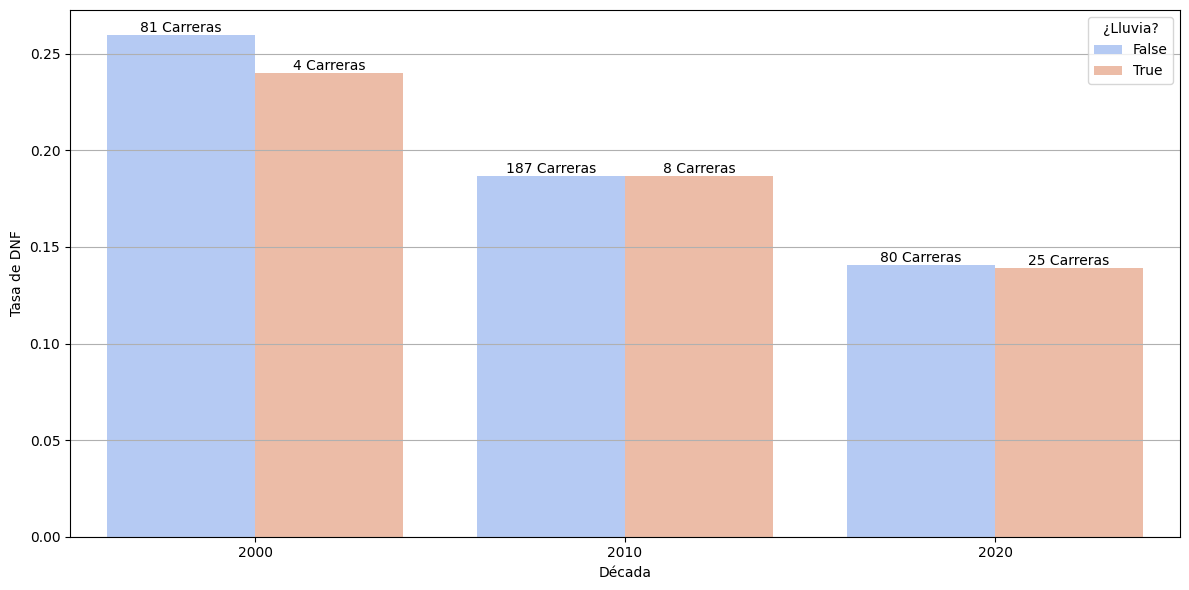

In [86]:
# Asegurar que 'decade' esté definida
df['decade'] = (df['year'] // 10) * 10

# Agrupar por década y lluvia, y calcular:
# - mean(dnf_rate)
# - cantidad de GPs únicos (raceId)
rain_decade_dnf = df.groupby(['decade', 'isRainy']).agg(
    dnf_rate_mean=('dnf_rate', 'mean'),
    gp_count=('raceId', pd.Series.nunique)
).reset_index()

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=rain_decade_dnf, x='decade', y='dnf_rate_mean', hue='isRainy', palette='coolwarm')

plt.xlabel('Década')
plt.ylabel('Tasa de DNF')
plt.legend(title='¿Lluvia?')

# Mostrar el número de carreras (GPs únicos) por barra
for bars, (_, group) in zip(ax.containers, rain_decade_dnf.groupby('isRainy')):
    labels = [f"{int(n)} Carreras" for n in group['gp_count']]
    ax.bar_label(bars, labels=labels, label_type='edge')

plt.grid(axis='y')
plt.tight_layout()
plt.show()


C:\Users\salva\AppData\Local\Temp\ipykernel_1932\1186105663.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rain_dnf, x='isRainy', y='dnf_rate_mean', palette='coolwarm')


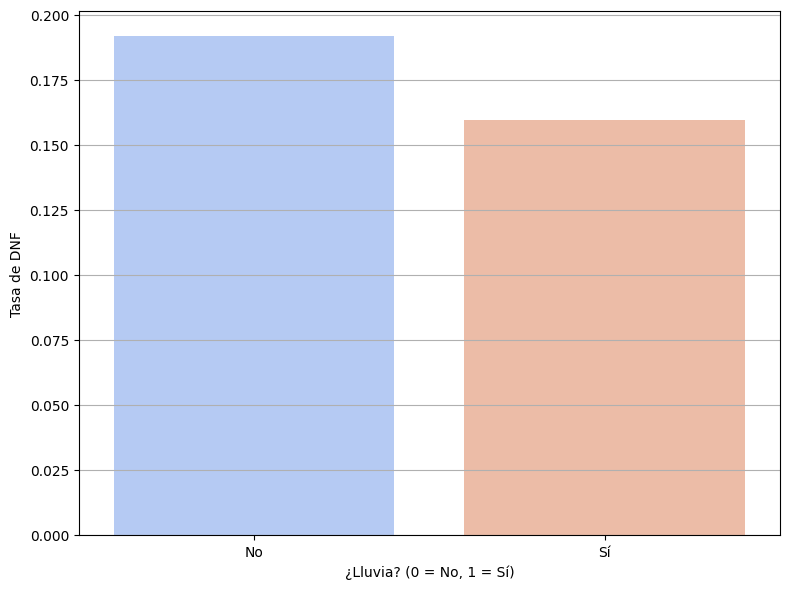

In [87]:
# Paso 1: calcular tasa de DNF y condición de lluvia por GP
race_stats_rain = df.groupby('raceId').agg(
    dnf_rate=('dnf_rate', 'mean'),
    isRainy=('isRainy', 'first')  # asumimos que es consistente dentro de cada carrera
).reset_index()

# Paso 2: agrupar por condición de lluvia
rain_dnf = race_stats_rain.groupby('isRainy').agg(
    dnf_rate_mean=('dnf_rate', 'mean'),
    gp_count=('raceId', 'count')
).reset_index()

# Paso 3: graficar
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=rain_dnf, x='isRainy', y='dnf_rate_mean', palette='coolwarm')

# Etiquetas y formato
plt.xlabel('¿Lluvia? (0 = No, 1 = Sí)')
plt.ylabel('Tasa de DNF')
plt.xticks([0, 1], ['No', 'Sí'])
plt.grid(axis='y')


plt.tight_layout()
plt.show()
